# Subscriptions EDA — `g4o_subscriptions` (dashboard MySQL)\n
\n
Exploratory data analysis on subscription billing, revenue, and churn metrics.

## 1. Setup & Connection

In [1]:
import os
import warnings
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 4), "figure.dpi": 110})

MYSQL_HOST = os.environ.get("MYSQL_HOST", "127.0.0.1")
MYSQL_PORT = int(os.environ.get("MYSQL_PORT", "3306"))
MYSQL_USER = os.environ.get("MYSQL_USER", "root")
MYSQL_PASSWORD = os.environ.get("MYSQL_PASSWORD", "bansila_root")
MYSQL_DB = os.environ.get("MYSQL_DATABASE", "bansila_analytics")

engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}",
    pool_pre_ping=True,
)
conn = engine.connect()
print(f"Connected: {MYSQL_DB} @ {MYSQL_HOST}:{MYSQL_PORT} as {MYSQL_USER}")


Connected: bansila_analytics @ 127.0.0.1:3306 as root


## 2. Data Overview & Temporary Slice

In [2]:
# Drop and recreate temp table for the session
conn.execute(text("DROP TEMPORARY TABLE IF EXISTS tmp_subscriptions"))
conn.commit()

# Exclude test company 97 and keep only valid companies
ddl = text("""
CREATE TEMPORARY TABLE tmp_subscriptions AS
SELECT *
FROM g4o_subscriptions
WHERE company_id IS NOT NULL AND company_id != 97
""")
conn.execute(ddl)
conn.commit()

# Basic shape and dates
meta = pd.read_sql(text("""
    SELECT 
        COUNT(*) as n_rows,
        COUNT(DISTINCT company_id) as n_companies,
        MIN(date) as min_date,
        MAX(date) as max_date
    FROM tmp_subscriptions
"""), conn)
display(meta)

# Sample rows
sample_df = pd.read_sql(text("SELECT * FROM tmp_subscriptions LIMIT 5"), conn)
display(sample_df)


,n_rows,n_companies,min_date,max_date
0,15572,6074,2020-01-17,2027-02-09


,id,company_id,tax,amount,total,status,currency_code,date,start_date,end_date,...,receipt_path,applied,referral_code,receipt_number,deleted_at,created_at,updated_at,discount_amount,subtotal,request
0,1,193,96000.0,1056000.0,960000.0,receipt,LAK,2020-01-17,2019-09-09,2020-12-09,...,/var/www/storage/app/uploads/97/invoices/recei...,0,None,00001,None,2021-09-15 22:58:29,2022-03-31 15:18:27,0.0,960000.0,
1,2,170,96000.0,1056000.0,960000.0,receipt,LAK,2020-01-17,2019-10-10,2021-01-10,...,/var/www/storage/app/uploads/97/invoices/recei...,0,None,00002,None,2021-09-15 22:58:29,2022-03-31 15:18:27,0.0,960000.0,
2,3,214,96000.0,1056000.0,960000.0,receipt,LAK,2020-01-17,2019-10-29,2021-01-29,...,/var/www/storage/app/uploads/97/invoices/recei...,0,None,INV00004,None,2021-09-15 22:58:29,2022-03-31 15:18:27,0.0,960000.0,
3,4,351,8000.0,88000.0,80000.0,receipt,LAK,2020-01-17,2019-12-24,2020-01-24,...,/var/www/storage/app/uploads/97/invoices/recei...,0,None,RE00004,None,2021-09-15 22:58:29,2022-03-31 15:18:27,0.0,80000.0,
4,5,203,8000.0,88000.0,80000.0,receipt,LAK,2020-01-17,2019-12-23,2020-01-23,...,/var/www/storage/app/uploads/97/invoices/recei...,0,None,RE00005,None,2021-09-15 22:58:29,2022-03-31 15:18:27,0.0,80000.0,


## 3. Status Distributio

,status,count
0,receipt,8877
1,invoice,5893
2,reward,802


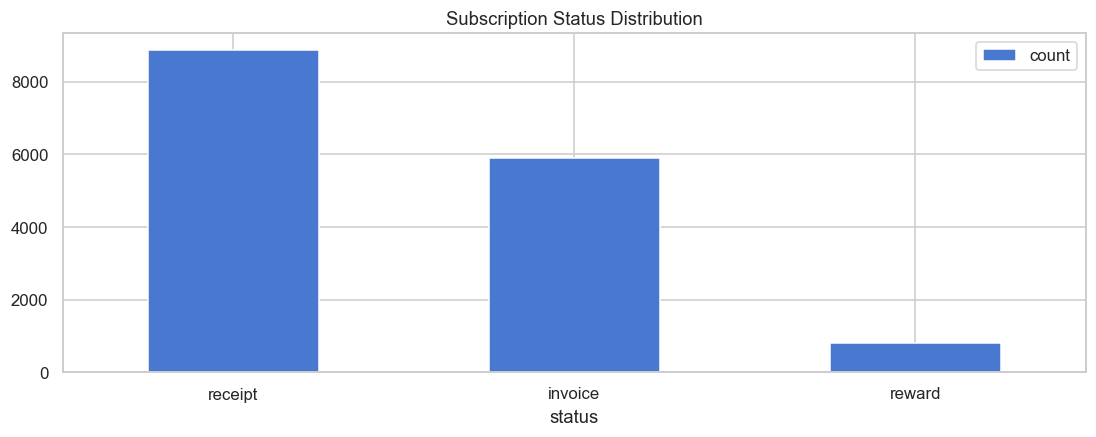

In [3]:
status_df = pd.read_sql(text("""
    SELECT status, COUNT(*) as count
    FROM tmp_subscriptions
    GROUP BY status
    ORDER BY count DESC
"""), conn)
display(status_df)
status_df.plot.bar(x='status', y='count', rot=0, title="Subscription Status Distribution")
plt.show()


## 4. Currency Analysis

In [4]:
currency_df = pd.read_sql(text("""
    SELECT currency_code, COUNT(*) as count, SUM(total) as total_revenue
    FROM tmp_subscriptions
    GROUP BY currency_code
    ORDER BY count DESC
"""), conn)
display(currency_df)


,currency_code,count,total_revenue
0,LAK,15572,8.964331e+09


## 5. Revenue Analysis

,amount,tax,discount_amount,subtotal,total
count,15572.00,15572.00,15572.00,15572.00,15572.00
mean,1053055.06,49984.09,29296.03,73696.89,575669.85
std,3436662.56,83778.15,225780.72,334325.16,922770.27
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00
50%,88000.00,8000.00,0.00,0.00,80000.00
75%,1056000.00,96000.00,0.00,0.00,960000.00
max,31680000.00,1720931.00,5460000.00,5280000.00,17209314.00


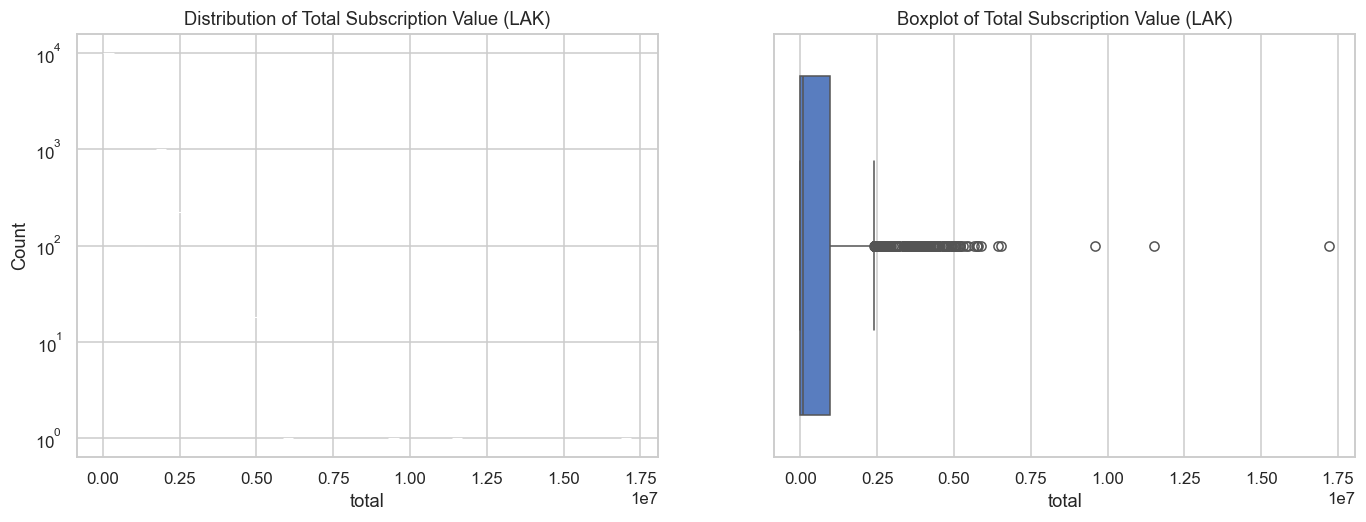

In [5]:
rev_df = pd.read_sql(text("""
    SELECT amount, tax, discount_amount, subtotal, total
    FROM tmp_subscriptions
    WHERE currency_code = 'LAK' -- focus on main currency for distribution
"""), conn)
display(rev_df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(rev_df['total'], bins=50, ax=axes[0], log_scale=(False, True))
axes[0].set_title("Distribution of Total Subscription Value (LAK)")
sns.boxplot(x=rev_df['total'], ax=axes[1])
axes[1].set_title("Boxplot of Total Subscription Value (LAK)")
plt.show()


## 6. Temporal Trends

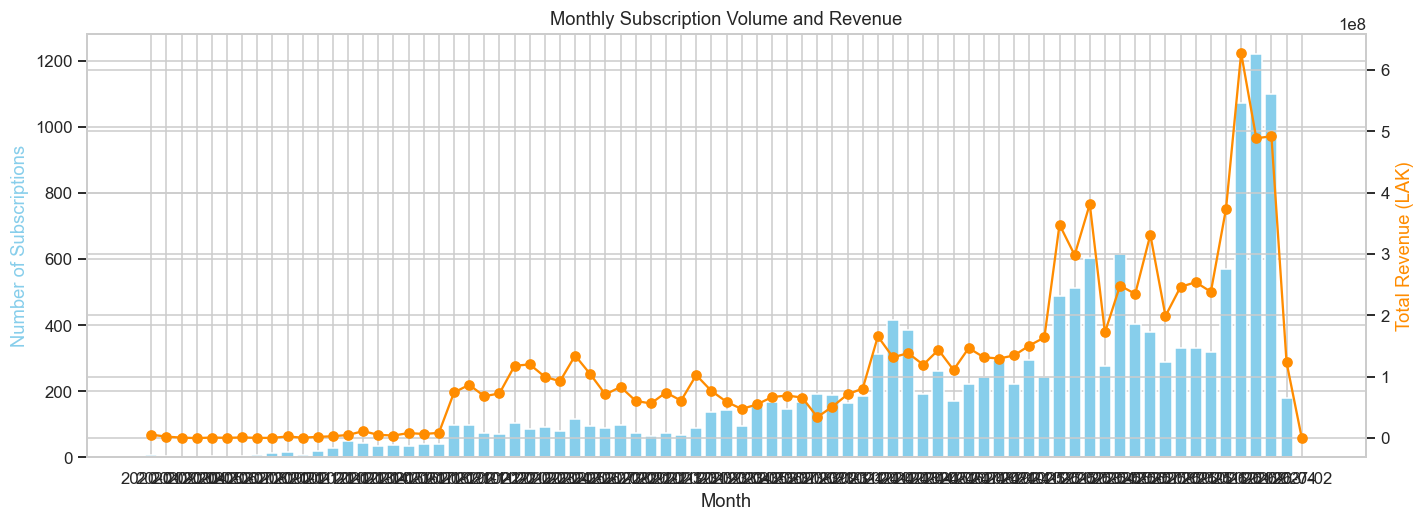

In [6]:
monthly_df = pd.read_sql(text("""
    SELECT 
        DATE_FORMAT(date, '%Y-%m') as month,
        COUNT(*) as num_subscriptions,
        SUM(CASE WHEN currency_code = 'LAK' THEN total ELSE 0 END) as total_revenue_lak
    FROM tmp_subscriptions
    GROUP BY month
    ORDER BY month
"""), conn)

fig, ax1 = plt.subplots(figsize=(15, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_df['month'], monthly_df['num_subscriptions'], color='skyblue', label='Volume')
ax2.plot(monthly_df['month'], monthly_df['total_revenue_lak'], color='darkorange', marker='o', label='Revenue (LAK)')

ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Subscriptions', color='skyblue')
ax2.set_ylabel('Total Revenue (LAK)', color='darkorange')
plt.xticks(rotation=45)
plt.title('Monthly Subscription Volume and Revenue')
plt.show()


## 7. Subscription Duration Analysis

,duration_days,count
0,0,5226
1,365,4056
2,31,2426
3,30,1065
4,28,444
5,366,440
6,181,174
7,184,135
8,92,111
9,29,105


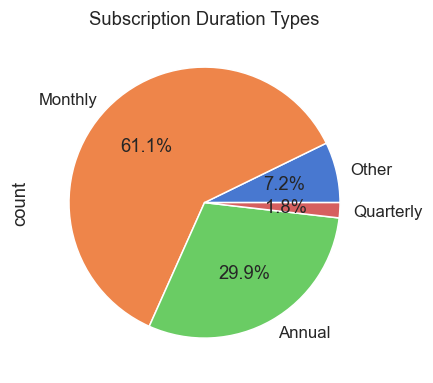

In [7]:
duration_df = pd.read_sql(text("""
    SELECT 
        DATEDIFF(end_date, start_date) as duration_days,
        COUNT(*) as count
    FROM tmp_subscriptions
    WHERE end_date >= start_date
    GROUP BY duration_days
    ORDER BY count DESC
    LIMIT 20
"""), conn)
display(duration_df)

# Categorize durations
cat_df = pd.read_sql(text("""
    SELECT 
        CASE 
            WHEN DATEDIFF(end_date, start_date) <= 31 THEN 'Monthly'
            WHEN DATEDIFF(end_date, start_date) BETWEEN 80 AND 100 THEN 'Quarterly'
            WHEN DATEDIFF(end_date, start_date) BETWEEN 350 AND 370 THEN 'Annual'
            ELSE 'Other'
        END as duration_type,
        COUNT(*) as count
    FROM tmp_subscriptions
    WHERE end_date >= start_date
    GROUP BY duration_type
"""), conn)
cat_df.plot.pie(y='count', labels=cat_df['duration_type'], autopct='%1.1f%%', legend=False, title="Subscription Duration Types")
plt.show()


## 8. Company-Level Analysis (Concentration)

,company_id,num_subscriptions,total_spend_lak
0,1365,6,30640000.0
1,2674,3,22249314.0
2,2013,7,20537206.0
3,3086,5,16851617.0
4,3785,6,15965096.0
5,2571,6,15240000.0
6,2470,7,15136438.0
7,1901,7,14206685.0
8,1934,6,13842740.0
9,1208,9,13745096.0


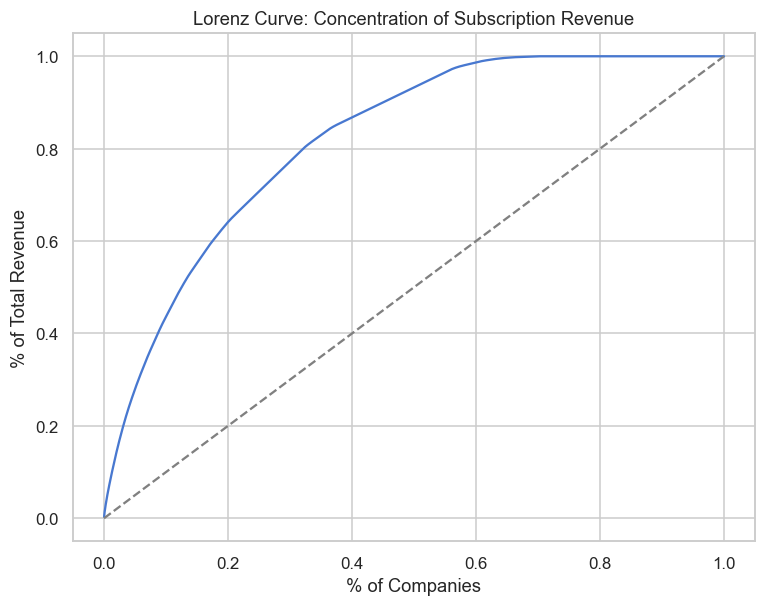

In [8]:
comp_df = pd.read_sql(text("""
    SELECT 
        company_id,
        COUNT(*) as num_subscriptions,
        SUM(CASE WHEN currency_code = 'LAK' THEN total ELSE 0 END) as total_spend_lak
    FROM tmp_subscriptions
    GROUP BY company_id
    ORDER BY total_spend_lak DESC
"""), conn)
display(comp_df.head(10))

# Lorenz Curve for Revenue Concentration
comp_df['cumulative_spend'] = comp_df['total_spend_lak'].cumsum()
comp_df['cumulative_pct'] = comp_df['cumulative_spend'] / comp_df['total_spend_lak'].sum()
comp_df['company_pct'] = np.arange(1, len(comp_df) + 1) / len(comp_df)

plt.figure(figsize=(8, 6))
plt.plot(comp_df['company_pct'], comp_df['cumulative_pct'])
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.title("Lorenz Curve: Concentration of Subscription Revenue")
plt.xlabel("% of Companies")
plt.ylabel("% of Total Revenue")
plt.show()


## 9. Referral Analysis

In [9]:
ref_df = pd.read_sql(text("""
    SELECT 
        CASE WHEN referral_code IS NULL OR referral_code = '' THEN 'No Referral' ELSE 'With Referral' END as has_referral,
        COUNT(*) as count,
        SUM(CASE WHEN currency_code = 'LAK' THEN total ELSE 0 END) as total_revenue
    FROM tmp_subscriptions
    GROUP BY has_referral
"""), conn)
display(ref_df)

top_refs = pd.read_sql(text("""
    SELECT referral_code, COUNT(*) as count
    FROM tmp_subscriptions
    WHERE referral_code IS NOT NULL AND referral_code != ''
    GROUP BY referral_code
    ORDER BY count DESC
    LIMIT 10
"""), conn)
display(top_refs)


,has_referral,count,total_revenue
0,No Referral,14715,8.573107e+09
1,With Referral,857,3.912242e+08


,referral_code,count
0,FREE,759
1,ທົດລອງອີກຄັ້ງ,34
2,0286,24
3,BANSI2020,20
4,BANSI2021,5
5,KHUKDHAI,3
6,F8FDC6,3
7,61C157,3
8,581987,1
9,BANSI2022,1


## 10. Soft Delete Analysis

In [10]:
del_df = pd.read_sql(text("""
    SELECT 
        CASE WHEN deleted_at IS NULL THEN 'Active' ELSE 'Deleted' END as is_deleted,
        COUNT(*) as count
    FROM tmp_subscriptions
    GROUP BY is_deleted
"""), conn)
display(del_df)


,is_deleted,count
0,Active,15572


## 11. Revenue Segmentation

In [11]:
# Segment companies based on their total LAK spend
seg_df = pd.read_sql(text("""
    WITH company_totals AS (
        SELECT company_id, SUM(total) as total_spend
        FROM tmp_subscriptions
        WHERE currency_code = 'LAK'
        GROUP BY company_id
    )
    SELECT 
        CASE 
            WHEN total_spend = 0 THEN 'Free/Trial'
            WHEN total_spend < 1000000 THEN 'Low Tier (<1M LAK)'
            WHEN total_spend < 5000000 THEN 'Mid Tier (1M-5M LAK)'
            WHEN total_spend < 20000000 THEN 'High Tier (5M-20M LAK)'
            ELSE 'Enterprise (20M+ LAK)'
        END as spend_segment,
        COUNT(*) as num_companies,
        SUM(total_spend) as segment_revenue
    FROM company_totals
    GROUP BY spend_segment
    ORDER BY segment_revenue DESC
"""), conn)
display(seg_df)


,spend_segment,num_companies,segment_revenue
0,Mid Tier (1M-5M LAK),1880,4.641367e+09
1,High Tier (5M-20M LAK),394,2.916584e+09
2,Low Tier (<1M LAK),1974,1.332954e+09
3,Enterprise (20M+ LAK),3,7.342652e+07
4,Free/Trial,1823,0.000000e+00


## 12. MRR / ARR Estimatio

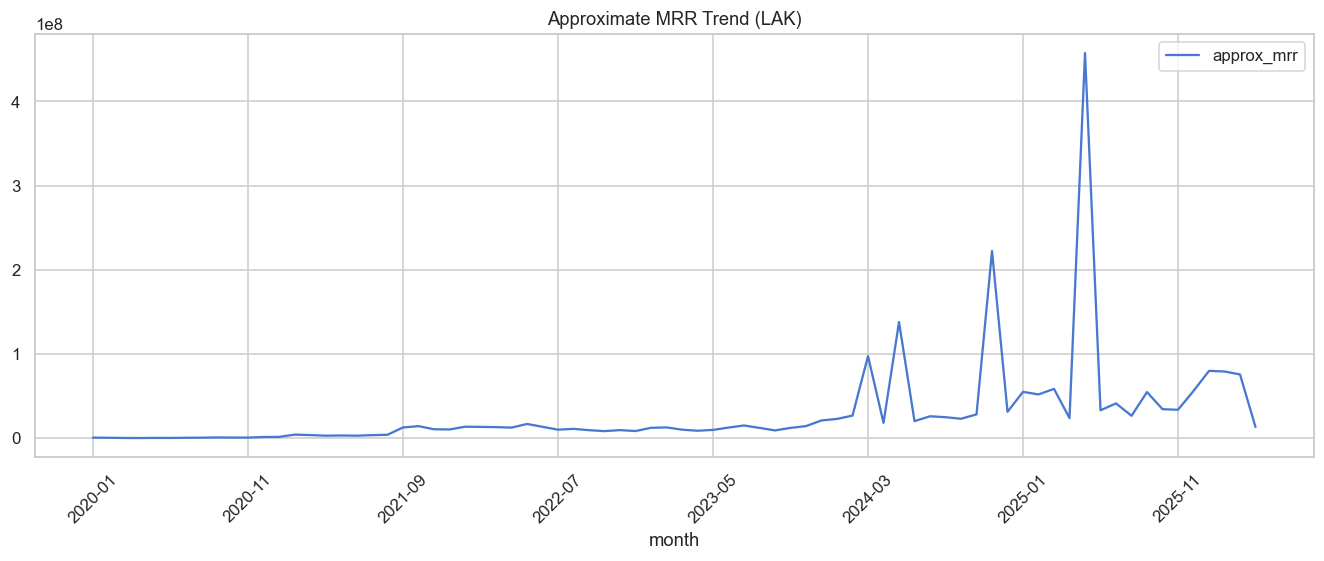

In [14]:
# Approximating monthly revenue by spreading subscription total over its duration
mrr_df = pd.read_sql(text("""
    SELECT 
        DATE_FORMAT(date, '%Y-%m') as month,
        SUM(CASE WHEN currency_code = 'LAK' THEN amount ELSE 0 END) / NULLIF(AVG(DATEDIFF(end_date, start_date)/30), 0) as approx_mrr
    FROM tmp_subscriptions
    WHERE end_date > start_date
    GROUP BY month
    ORDER BY month
"""), conn)
mrr_df.plot(x='month', y='approx_mrr', title="Approximate MRR Trend (LAK)", figsize=(15, 5))
plt.xticks(rotation=45)
plt.show()


## 13. Churn Indicators

In [13]:
# Look at companies whose last end_date is far in the past
churn_df = pd.read_sql(text("""
    SELECT 
        company_id,
        MAX(end_date) as last_subscription_end,
        DATEDIFF(CURDATE(), MAX(end_date)) as days_since_expiry
    FROM tmp_subscriptions
    GROUP BY company_id
    HAVING days_since_expiry > 30
    ORDER BY days_since_expiry DESC
"""), conn)
display(churn_df.head(10))
print(f"Total potential churned companies (>30 days since sub expired): {len(churn_df)}")


,company_id,last_subscription_end,days_since_expiry
0,204,2020-06-10,2165
1,381,2020-06-16,2159
2,678,2020-09-02,2081
3,780,2020-09-18,2065
4,370,2020-09-24,2059
5,791,2020-10-03,2050
6,809,2020-10-07,2046
7,806,2020-10-07,2046
8,549,2020-10-26,2027
9,821,2020-10-28,2025


Total potential churned companies (>30 days since sub expired): 3451


## 14. Key Findings & Actionable Insights

* **Revenue Concentration**: Review the Lorenz curve to understand reliance on top customers.\n
* **Duration Preferences**: Are users opting for Annual vs Monthly? Tailor pricing incentives accordingly.\n
* **Churn**: A significant number of companies may have expired subscriptions. Trigger automated renewal emails before `end_date`.\n
* **Referrals**: If referral usage is low, consider promoting the referral program more aggressively.

## Additional Stuff

### Pipeline conversion (invoice -> receipt)

This section estimates how often an `invoice`-status subscription eventually turns into a `receipt` (cash) for the same company, using each company\’s **first invoice start_date** as the cohort anchor.

,cohort_month,n_companies,n_converted,conversion_rate,median_time_to_conversion_days,sum_first_invoice_total,sum_receipts_total_after
73,2027-12-01,2,0,0.0,NaN,1920000.0,0.0
74,2028-01-01,2,0,0.0,NaN,1920000.0,0.0
75,2028-02-01,1,0,0.0,NaN,0.0,0.0
76,2028-03-01,1,0,0.0,NaN,0.0,0.0
77,2028-11-01,1,0,0.0,NaN,0.0,0.0
78,2028-12-01,1,0,0.0,NaN,0.0,0.0
79,2029-07-01,1,0,0.0,NaN,0.0,0.0
80,2029-12-01,2,1,0.5,0.0,960000.0,17209314.0
81,2030-03-01,1,0,0.0,NaN,2420000.0,0.0
82,2030-12-01,3,0,0.0,NaN,480000.0,0.0


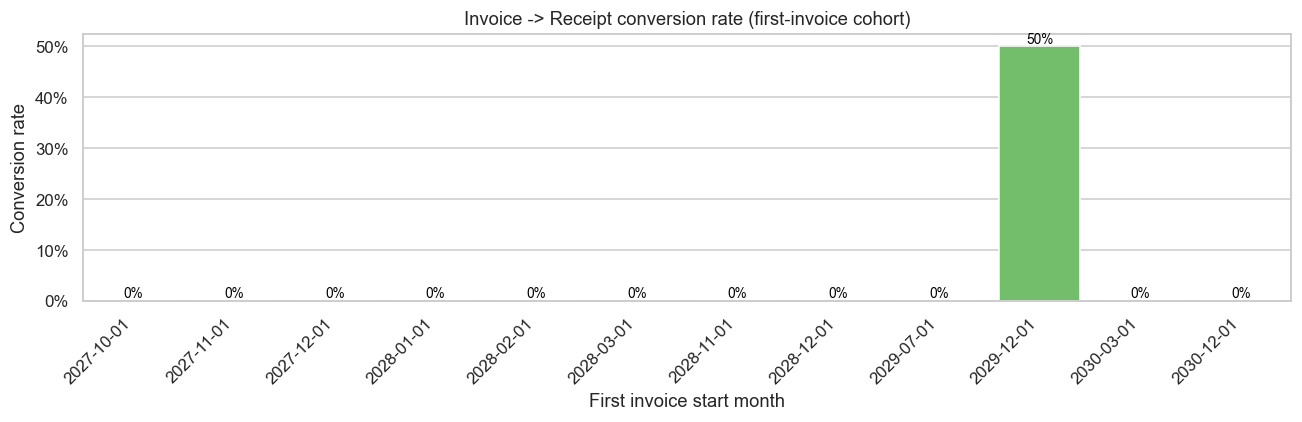

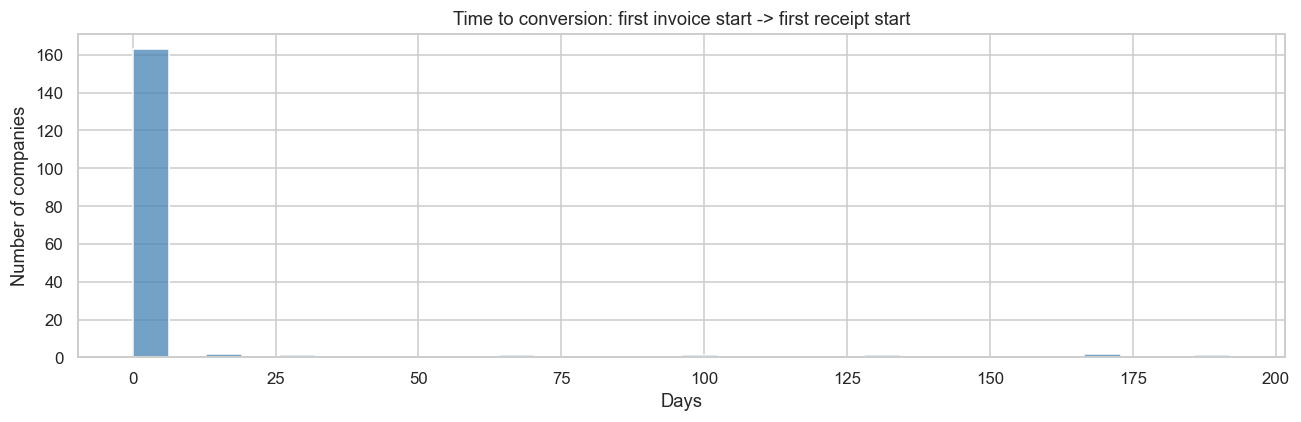

Top 10 fastest invoice->receipt conversions:


,company_id,first_invoice_start,first_receipt_start,time_to_conversion_days,first_invoice_total,receipts_total_after
56,785,2026-07-07,2026-07-07,0.0,0.0,904767.0
3610,6198,2026-01-22,2026-01-22,0.0,0.0,0.0
3714,6305,2027-02-26,2027-02-26,0.0,0.0,0.0
3719,6310,2026-02-05,2026-02-05,0.0,0.0,870575.0
3761,6352,2026-02-07,2026-02-07,0.0,0.0,78904.0
3832,6424,2025-05-18,2025-05-18,0.0,0.0,837260.0
3922,6515,2025-06-12,2025-06-12,0.0,0.0,92055.0
4078,6673,2026-12-22,2026-12-22,0.0,0.0,841644.0
3515,6101,2027-01-20,2027-01-20,0.0,0.0,765370.0
4083,6678,2026-01-23,2026-01-23,0.0,0.0,0.0


In [3]:
# Pipeline conversion: for each company, does the first `invoice` eventually have a later `receipt`?

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import text

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 4), "figure.dpi": 110})

# ---------------------------
# Load invoice/receipt rows
# ---------------------------

# Assumption: `conn` exists (created in an earlier cell).

subs_cols = "company_id, status, start_date, total, currency_code"
try:
    df = pd.read_sql(
        text(f"""
            SELECT {subs_cols}
            FROM g4o_subscriptions
            WHERE company_id IS NOT NULL
              AND status IN ('invoice','receipt')
        """),
        conn,
    )
except Exception:
    df = pd.read_sql(
        text("""
            SELECT company_id, status, start_date, total
            FROM g4o_subscriptions
            WHERE company_id IS NOT NULL
              AND status IN ('invoice','receipt')
        """),
        conn,
    )

# Parse + cast

df["start_date_dt"] = pd.to_datetime(df["start_date"], errors="coerce").dt.normalize()
df["total_num"] = pd.to_numeric(df.get("total"), errors="coerce").fillna(0.0)

# If currency exists: prefer LAK if present, else fall back to the most frequent currency.
if "currency_code" in df.columns:
    if "LAK" in set(df["currency_code"].dropna().unique()):
        df = df[df["currency_code"] == "LAK"].copy()
    else:
        common = df["currency_code"].mode(dropna=True)
        if len(common):
            df = df[df["currency_code"] == common.iloc[0]].copy()

# Drop rows with missing critical fields

df = df.dropna(subset=["company_id", "status", "start_date_dt"]).copy()

invoices = df[df["status"] == "invoice"].copy()
receipts = df[df["status"] == "receipt"].copy()

# ---------------------------
# First invoice cohort per company
# ---------------------------

first_invoice = (
    invoices.groupby("company_id", as_index=False)["start_date_dt"]
    .min()
    .rename(columns={"start_date_dt": "first_invoice_start"})
)

# First receipt on/after the first invoice start
receipts_after = receipts.merge(first_invoice, on="company_id", how="inner")
receipts_after = receipts_after[receipts_after["start_date_dt"] >= receipts_after["first_invoice_start"]]

first_receipt_after = (
    receipts_after.groupby("company_id", as_index=False)["start_date_dt"]
    .min()
    .rename(columns={"start_date_dt": "first_receipt_start"})
)

conv = first_invoice.merge(first_receipt_after, on="company_id", how="left")
conv["converted_to_receipt"] = conv["first_receipt_start"].notna()

# Time-to-conversion (days)
conv["time_to_conversion_days"] = (
    conv["first_receipt_start"] - conv["first_invoice_start"]
).dt.days

# Revenue proxy: invoice amount at the first invoice start + total receipt amount after it
# (This is optional/approximate; still useful for funnel sanity checks.)

invoice_amount = (
    invoices.merge(first_invoice, on="company_id", how="inner")
)
invoice_amount = invoice_amount[invoice_amount["start_date_dt"] == invoice_amount["first_invoice_start"]]
invoice_amount = invoice_amount.groupby("company_id", as_index=False)["total_num"].sum().rename(columns={"total_num": "first_invoice_total"})

receipt_amount_after = (
    receipts_after.groupby("company_id", as_index=False)["total_num"].sum().rename(columns={"total_num": "receipts_total_after"})
)

conv = conv.merge(invoice_amount, on="company_id", how="left")
conv = conv.merge(receipt_amount_after, on="company_id", how="left")
conv[["first_invoice_total", "receipts_total_after"]] = conv[["first_invoice_total", "receipts_total_after"]].fillna(0.0)

# ---------------------------
# Cohort metrics by first-invoice month
# ---------------------------

conv["cohort_month"] = conv["first_invoice_start"].dt.to_period("M").dt.to_timestamp()

cohort = (
    conv.groupby("cohort_month", as_index=False)
    .agg(
        n_companies=("company_id", "nunique"),
        n_converted=("converted_to_receipt", "sum"),
        conversion_rate=("converted_to_receipt", "mean"),
        median_time_to_conversion_days=("time_to_conversion_days", "median"),
        sum_first_invoice_total=("first_invoice_total", "sum"),
        sum_receipts_total_after=("receipts_total_after", "sum"),
    )
    .sort_values("cohort_month")
)

# Helper for plotting recent range
cohort_plot = cohort.sort_values("cohort_month").tail(12).copy()

display(cohort.tail(10))

plt.figure(figsize=(12, 4))
ax = sns.barplot(data=cohort_plot, x="cohort_month", y="conversion_rate", palette="viridis")
ax.set_title("Invoice -> Receipt conversion rate (first-invoice cohort)")
ax.set_xlabel("First invoice start month")
ax.set_ylabel("Conversion rate")

plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")

# Label bars
for p in ax.patches:
    if p.get_height() is None:
        continue
    ax.annotate(f"{p.get_height()*100:.0f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9, color="black")

plt.tight_layout()
plt.show()

# ---------------------------
# Time-to-conversion distribution
# ---------------------------

converted_only = conv[conv["converted_to_receipt"]].copy()

plt.figure(figsize=(12, 4))
ax = sns.histplot(converted_only["time_to_conversion_days"].dropna(), bins=30, kde=False, color="steelblue")
ax.set_title("Time to conversion: first invoice start -> first receipt start")
ax.set_xlabel("Days")
ax.set_ylabel("Number of companies")
plt.tight_layout()
plt.show()

# ---------------------------
# Show top fastest conversions
# ---------------------------

fastest = (
    converted_only.sort_values("time_to_conversion_days")
    .head(10)[["company_id", "first_invoice_start", "first_receipt_start", "time_to_conversion_days", "first_invoice_total", "receipts_total_after"]]
    .copy()
)

print("Top 10 fastest invoice->receipt conversions:")
display(fastest)
